# Fine-tuning IndoBERT untuk *Composite Risk Scoring* Berita Indonesia

Notebook ini mengimplementasikan pilar NLP pada **Arsitektur Datathon Underdogs**: deteksi clickbait/framing, emosi pemicu chaos, pola propaganda, dan *market relevance*. Komponen semantic similarity terhadap basis hoaks serta uji Granger terhadap IHSG adalah tahap hilir yang memerlukan data eksternal, sehingga sengaja tidak dipalsukan sebagai hasil supervised learning dari dataset ini.

## 1. Pendahuluan

### Review kritis arsitektur dan dataset (source of truth)
Arsitektur menetapkan IndoBERT untuk risiko linguistik/clickbait dan sentimen kontekstual, semantic search untuk kemiripan propaganda, lalu Granger causality untuk dampak pasar. Empat label dataset selaras dengan empat sinyal operasional: `clickbait_framing`, `chaos_prone_emotion`, `propaganda_pattern`, dan `market_relevance`.

**Rekomendasi yang tidak mengubah arsitektur:**

- Gunakan **multi-task IndoBERT**: satu encoder bersama dan empat classification head. Semua label berasal dari artikel yang sama; encoder bersama menghemat inferensi real-time dan memungkinkan sinyal terkait saling memperkaya. Simpan baseline empat single-task model untuk mendeteksi *negative transfer*.
- Clickbait seharusnya diuji juga dengan `title` saja, karena arsitektur menyebut tajuk. Notebook memakai pasangan `title [SEP] content_clean` agar keputusan tetap kontekstual; evaluasi ablation title-only wajib dilakukan sebelum rilis.
- `chaos_prone_emotion` bukan sinonim langsung dari *sentiment*. Karena itu label ini dilatih sebagai task tersendiri, bukan diklaim sebagai model sentimen umum. Pedoman anotasi perlu mendefinisikan jelas kelas `uncertain`.
- Kelas minoritas—terutama propaganda `yes` (64 contoh)—membuat akurasi menyesatkan. Notebook memakai bobot kelas dan macro-F1, tetapi penambahan gold labels, adjudication antar-anotator, dan active learning untuk kelas minoritas tetap prioritas.
- Semua 6.000 baris berstatus `silver_labeled`; metrik test mengukur kesesuaian terhadap silver label, bukan ground truth. Buat gold test set yang dibekukan dan dianotasi ganda sebelum klaim produksi.
- Label `market_relevance` adalah tag supervised, bukan bukti kausalitas. Granger/VAR hanya boleh dijalankan setelah skor risiko diagregasi per waktu dan digabung dengan seri IHSG yang stasioner serta diuji lag, *confounder*, dan out-of-sample.
- `rationale`, `annotator_id`, dan `annotation_status` dilarang menjadi fitur input agar tidak terjadi data leakage.

## 2. Import Library

Instalasi bersifat idempoten. Jalankan notebook pada environment dengan GPU CUDA bila tersedia; ia tetap berjalan pada CPU.

In [1]:
import importlib.util
from importlib.metadata import PackageNotFoundError, version
from packaging.version import Version
import subprocess
import sys

import torch, transformers
print(torch.__version__)         # harus 2.6.0
print(transformers.__version__)  # harus 4.46.3
print(torch.backends.mps.is_available())  # harus True

REQUIRED = {
    'numpy': 'numpy==1.26.4',
    'pandas': 'pandas==2.2.2',
    'matplotlib': 'matplotlib==3.8.4',
    'torch': 'torch>=2.6',
    'torchvision': 'torchvision==0.21.0',
    'transformers': 'transformers==4.46.3',
    'safetensors': 'safetensors>=0.4.3',
    'iterstrat': 'iterative-stratification>=0.1.7',
    'sklearn': 'scikit-learn==1.5.1',
    'seaborn': 'seaborn==0.13.2',
}
missing = [package for module, package in REQUIRED.items() if importlib.util.find_spec(module) is None]
# Model ini hanya menyediakan pytorch_model.bin (bukan safetensors), sehingga Transformers
# memerlukan PyTorch >=2.6 untuk memuatnya secara aman (CVE-2025-32434).
torch_needs_upgrade = False
transformers_needs_change = False
analysis_stack_needs_change = False
torchvision_needs_change = False
try:
    torch_needs_upgrade = Version(version('torch').split('+')[0]) < Version('2.6')
except PackageNotFoundError:
    torch_needs_upgrade = True
try:
    torchvision_needs_change = Version(version('torchvision')) != Version('0.21.0')
except PackageNotFoundError:
    torchvision_needs_change = True
try:
    transformers_needs_change = Version(version('transformers')) != Version('4.46.3')
except PackageNotFoundError:
    transformers_needs_change = True
PINNED_ANALYSIS_STACK = {
    'numpy': '1.26.4', 'pandas': '2.2.2', 'matplotlib': '3.8.4',
    'scikit-learn': '1.5.1', 'seaborn': '0.13.2',
}
try:
    analysis_stack_needs_change = any(version(name) != target for name, target in PINNED_ANALYSIS_STACK.items())
except PackageNotFoundError:
    analysis_stack_needs_change = True
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', *missing])
if torch_needs_upgrade:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', 'torch>=2.6'])
if torchvision_needs_change:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', '--force-reinstall',
                           'torchvision==0.21.0'])
if transformers_needs_change:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', '--force-reinstall',
                           'transformers==4.46.3', 'tokenizers>=0.20,<0.21'])
if analysis_stack_needs_change:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--upgrade', '--force-reinstall',
                           'numpy==1.26.4', 'pandas==2.2.2', 'matplotlib==3.8.4',
                           'scikit-learn==1.5.1', 'seaborn==0.13.2'])
if torch_needs_upgrade or torchvision_needs_change or transformers_needs_change or analysis_stack_needs_change:
    raise RuntimeError('Dependensi telah diperbarui. Restart kernel Jupyter, lalu jalankan notebook dari cell ini.')

import json
from contextlib import nullcontext
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from safetensors.torch import load_file, save_file
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             f1_score, precision_recall_fscore_support)
from torch.optim.lr_scheduler import LambdaLR
from torch.utils.data import DataLoader, Dataset
from transformers import (AutoModel, AutoTokenizer,
                          DataCollatorWithPadding)

print(f'PyTorch: {torch.__version__} | CUDA available: {torch.cuda.is_available()} | MPS available: {torch.backends.mps.is_available()}')

2.6.0
4.46.3
True
PyTorch: 2.6.0 | CUDA available: False | MPS available: True


## 3. Konfigurasi

`indobenchmark/indobert-base-p2` dipilih karena merupakan encoder IndoBERT base yang dipra-latih untuk bahasa Indonesia dan memberi kompromi kualitas/latensi yang baik untuk RSS real-time. Gunakan `indobert-large-p2` hanya setelah baseline ini stabil dan GPU memadai.

In [2]:
SEED = 42
MODEL_NAME = 'indobenchmark/indobert-base-p2'
MAX_LENGTH = 384          # cukup untuk judul + konteks artikel, aman untuk GPU menengah
BATCH_SIZE = 8            # naikkan bila memori GPU mencukupi
GRADIENT_ACCUMULATION = 4 # effective batch size = 32
EPOCHS = 5
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
DROPOUT = 0.15
NUM_WORKERS = 0

DATA_PATH = Path('/Users/kaleee/project-2026/datathon-ui-2026/data/labeled_6000.csv')
ARTIFACT_DIR = Path('artifacts/indobert_multitask')
CHECKPOINT_DIR = ARTIFACT_DIR / 'checkpoints'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TASKS = {
    'clickbait_framing_label': ['no', 'yes', 'uncertain'],
    'chaos_prone_emotion_label': ['no', 'yes', 'uncertain'],
    'propaganda_pattern_label': ['no', 'yes', 'uncertain'],
    'market_relevance_label': ['A', 'B', 'C'],
}

def seed_everything(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
# CUDA untuk NVIDIA; MPS adalah akselerasi Apple Silicon (M1/M2/M3); CPU sebagai fallback.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

USE_CUDA_AMP = DEVICE.type == 'cuda'
def autocast_context():
    return torch.amp.autocast(device_type='cuda', enabled=True) if USE_CUDA_AMP else nullcontext()

print(f'Device selected: {DEVICE}')

Device selected: mps


## 4. Load Dataset

Validasi skema dilakukan lebih awal agar training tidak berjalan dengan input atau label yang salah.

In [3]:
REQUIRED_COLUMNS = {'article_id', 'source', 'published_at', 'title', 'content_clean',
                    'annotator_id', 'annotation_status', 'rationale', *TASKS.keys()}
assert DATA_PATH.exists(), f'Dataset tidak ditemukan: {DATA_PATH.resolve()}'
df = pd.read_csv(DATA_PATH)
missing_columns = REQUIRED_COLUMNS - set(df.columns)
assert not missing_columns, f'Kolom wajib hilang: {missing_columns}'
assert df['article_id'].is_unique, 'article_id harus unik sebelum split'
for task, classes in TASKS.items():
    observed = set(df[task].dropna().astype(str).str.strip())
    assert observed <= set(classes), f'Label tak dikenal pada {task}: {observed - set(classes)}'
print(f'Rows: {len(df):,}; columns: {len(df.columns)}')
df.head(3)

Rows: 6,000; columns: 12


,article_id,source,published_at,title,content_clean,clickbait_framing_label,chaos_prone_emotion_label,propaganda_pattern_label,market_relevance_label,annotator_id,annotation_status,rationale
0,0d544f4e-417c-5166-b871-be9a93398e6e,kompas,2024-07-31 00:00:00,"Diprotes Sopir JakLingko soal Sistem Upah, Tra...",PT TransJakarta mengeklaim telah berlaku adil ...,no,no,no,B,A,silver_labeled,Berita faktual berbasis kutipan resmi tanpa fr...
1,418656ba-855c-5d01-a555-2a5ecb5a5e46,kompas,2024-07-31 00:00:00,"Hary Tanoe Mundur dari Ketum Perindo, Tunjuk A...",Ketua Umum Partai Perindo Hary Tanoesoedibjo m...,no,no,no,B,A,silver_labeled,Berita politik internal partai yang disampaika...
2,7441a7fe-825c-55b8-b3f7-9b51cbc19680,kompas,2024-07-31 00:00:00,Wakasek: Gedung SDN 01 Pondok Bambu yang Terba...,Wakil Kepala Sekolah Bidang Kurikulum SDN 01 P...,no,no,no,C,A,silver_labeled,Berita faktual tentang renovasi sekolah tanpa ...


## 5. Exploratory Data Analysis singkat

Distribusi label menentukan perlunya weighted loss dan macro-F1. EDA ini juga memeriksa panjang input untuk mengaudit truncation.

,clickbait_framing_label,chaos_prone_emotion_label,propaganda_pattern_label,market_relevance_label
A,NaN,NaN,NaN,366.0
B,NaN,NaN,NaN,2592.0
C,NaN,NaN,NaN,3042.0
no,5657.0,5620.0,5814.0,NaN
uncertain,159.0,200.0,122.0,NaN
yes,184.0,180.0,64.0,NaN


,,count
source,annotation_status,
kompas,silver_labeled,3153
tempo,silver_labeled,2248
detik,silver_labeled,599


count     6000.000000
mean      2340.020333
std       1004.283781
min        110.000000
50%       2208.000000
90%       3441.100000
95%       4052.200000
99%       6129.030000
max      11743.000000
Name: char_length, dtype: float64


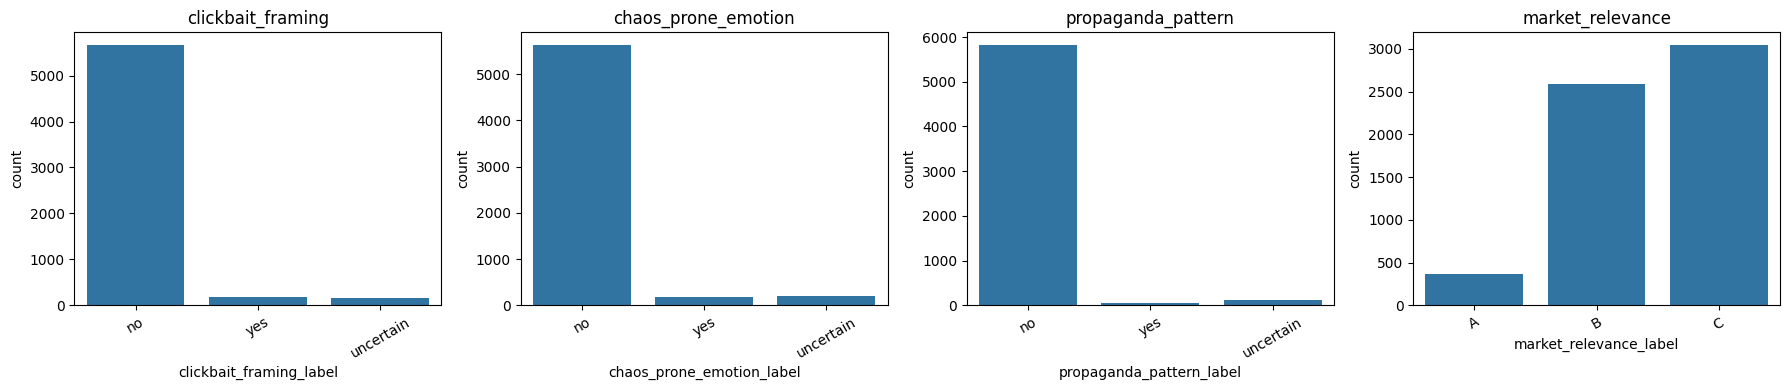

In [4]:
display(df[list(TASKS)].apply(lambda x: x.value_counts(dropna=False)))
display(df[['source', 'annotation_status']].value_counts().rename('count').to_frame())
df['char_length'] = df['title'].fillna('').str.len() + df['content_clean'].fillna('').str.len()
print(df['char_length'].describe(percentiles=[.5, .9, .95, .99]))
fig, axes = plt.subplots(1, len(TASKS), figsize=(18, 4))
for ax, task in zip(axes, TASKS):
    sns.countplot(data=df, x=task, order=TASKS[task], ax=ax)
    ax.set_title(task.replace('_label', '')); ax.tick_params(axis='x', rotation=30)
plt.tight_layout()

## 6. Data Preprocessing

Gunakan teks bersih minimal—hapus URL/whitespace dan normalisasi Unicode. Jangan melakukan stemming atau stopword removal karena tokenizer Transformer memerlukan konteks asli. Baris tanpa judul atau konten dibuang; metadata, rationale, serta kolom annotator tidak masuk fitur.

In [5]:
import re
import unicodedata

def clean_text(text):
    text = unicodedata.normalize('NFKC', str(text))
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

model_df = df.copy()
model_df['title'] = model_df['title'].fillna('').map(clean_text)
model_df['content_clean'] = model_df['content_clean'].fillna('').map(clean_text)
for task in TASKS:
    model_df[task] = model_df[task].astype(str).str.strip()
before = len(model_df)
model_df = model_df[(model_df['title'] != '') & (model_df['content_clean'] != '')].copy()
print(f'Baris dipakai: {len(model_df):,}; dibuang karena teks kosong: {before-len(model_df):,}')

Baris dipakai: 6,000; dibuang karena teks kosong: 0


## 7. Label Encoding

Encoding disimpan sebagai artefak agar inference selalu menggunakan urutan kelas yang identik dengan training.

In [6]:
LABEL2ID = {task: {label: i for i, label in enumerate(classes)} for task, classes in TASKS.items()}
ID2LABEL = {task: {i: label for label, i in mapping.items()} for task, mapping in LABEL2ID.items()}
for task, mapping in LABEL2ID.items():
    model_df[f'{task}_id'] = model_df[task].map(mapping).astype('int64')
with open(ARTIFACT_DIR / 'label_mappings.json', 'w', encoding='utf-8') as f:
    json.dump({'label2id': LABEL2ID, 'id2label': ID2LABEL}, f, ensure_ascii=False, indent=2)
LABEL2ID

{'clickbait_framing_label': {'no': 0, 'yes': 1, 'uncertain': 2},
 'chaos_prone_emotion_label': {'no': 0, 'yes': 1, 'uncertain': 2},
 'propaganda_pattern_label': {'no': 0, 'yes': 1, 'uncertain': 2},
 'market_relevance_label': {'A': 0, 'B': 1, 'C': 2}}

## 8. Train Validation Test Split

Gunakan iterative multilabel stratification 80/10/10 agar distribusi empat label dipertahankan. Untuk produksi, lakukan audit tambahan deduplikasi near-duplicate dan, bila ada artikel yang sama lintas sumber, gunakan group split berdasarkan cluster konten.

In [7]:
# Iterative stratification membutuhkan indikator biner; one-hot menjaga setiap kelas tiap task.
y_multi = np.concatenate([
    pd.get_dummies(model_df[f'{task}_id']).reindex(columns=range(len(TASKS[task])), fill_value=0).to_numpy()
    for task in TASKS
], axis=1)
indices = np.arange(len(model_df))
split_1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
train_idx, holdout_idx = next(split_1.split(indices, y_multi))
split_2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_relative, test_relative = next(split_2.split(holdout_idx, y_multi[holdout_idx]))
train_df = model_df.iloc[train_idx].reset_index(drop=True)
val_df = model_df.iloc[holdout_idx[val_relative]].reset_index(drop=True)
test_df = model_df.iloc[holdout_idx[test_relative]].reset_index(drop=True)
assert set(train_df.article_id).isdisjoint(val_df.article_id)
assert set(train_df.article_id).isdisjoint(test_df.article_id)
assert set(val_df.article_id).isdisjoint(test_df.article_id)
for name, split in {'train': train_df, 'val': val_df, 'test': test_df}.items():
    print(name, len(split), {task: split[task].value_counts().to_dict() for task in TASKS})
train_df.to_csv(ARTIFACT_DIR / 'train_split.csv', index=False)
val_df.to_csv(ARTIFACT_DIR / 'validation_split.csv', index=False)
test_df.to_csv(ARTIFACT_DIR / 'test_split.csv', index=False)

train 4800 {'clickbait_framing_label': {'no': 4526, 'yes': 147, 'uncertain': 127}, 'chaos_prone_emotion_label': {'no': 4496, 'uncertain': 160, 'yes': 144}, 'propaganda_pattern_label': {'no': 4651, 'uncertain': 98, 'yes': 51}, 'market_relevance_label': {'C': 2433, 'B': 2074, 'A': 293}}
val 600 {'clickbait_framing_label': {'no': 565, 'yes': 19, 'uncertain': 16}, 'chaos_prone_emotion_label': {'no': 562, 'uncertain': 20, 'yes': 18}, 'propaganda_pattern_label': {'no': 582, 'uncertain': 12, 'yes': 6}, 'market_relevance_label': {'C': 305, 'B': 259, 'A': 36}}
test 600 {'clickbait_framing_label': {'no': 566, 'yes': 18, 'uncertain': 16}, 'chaos_prone_emotion_label': {'no': 562, 'uncertain': 20, 'yes': 18}, 'propaganda_pattern_label': {'no': 581, 'uncertain': 12, 'yes': 7}, 'market_relevance_label': {'C': 304, 'B': 259, 'A': 37}}


## 9. Tokenization

Tokenizer menerima pasangan judul dan isi artikel. `truncation='only_second'` menjaga judul utuh dan memangkas konten jika melebihi `MAX_LENGTH`.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
example = tokenizer(train_df.loc[0, 'title'], train_df.loc[0, 'content_clean'],
                    truncation='only_second', max_length=MAX_LENGTH)
print(f'Contoh token length: {len(example["input_ids"])} / {MAX_LENGTH}')

Contoh token length: 384 / 384


## 10. Dataset & DataLoader

Dynamic padding melalui data collator menekan pemborosan memori. Dataset hanya mengekspos teks dan empat target numerik.

In [9]:
class NewsMultiTaskDataset(Dataset):
    def __init__(self, frame, tokenizer, max_length):
        self.frame = frame.reset_index(drop=True)
        self.tokenizer, self.max_length = tokenizer, max_length
    def __len__(self): return len(self.frame)
    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        item = self.tokenizer(row.title, row.content_clean, truncation='only_second',
                              max_length=self.max_length)
        item['labels'] = torch.tensor([row[f'{task}_id'] for task in TASKS], dtype=torch.long)
        return item

collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')
def collate_batch(features):
    labels = torch.stack([f.pop('labels') for f in features])
    batch = collator(features); batch['labels'] = labels
    return batch

train_loader = DataLoader(NewsMultiTaskDataset(train_df, tokenizer, MAX_LENGTH), BATCH_SIZE, shuffle=True,
                          collate_fn=collate_batch, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')
val_loader = DataLoader(NewsMultiTaskDataset(val_df, tokenizer, MAX_LENGTH), BATCH_SIZE, shuffle=False,
                        collate_fn=collate_batch, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')
test_loader = DataLoader(NewsMultiTaskDataset(test_df, tokenizer, MAX_LENGTH), BATCH_SIZE, shuffle=False,
                         collate_fn=collate_batch, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == 'cuda')

## 11. Model Initialization

Satu backbone IndoBERT dan empat head softmax mempertahankan sinyal terpisah untuk Composite Risk Scoring. Weighted cross-entropy dihitung dari train split saja untuk mencegah leakage.

In [10]:
assert Version(torch.__version__.split('+')[0]) >= Version('2.6'), (
    f'PyTorch {torch.__version__} tidak cukup. Upgrade ke >=2.6 lalu restart kernel.'
)
assert Version(__import__('transformers').__version__) == Version('4.46.3'), (
    'Transformers harus tepat versi 4.46.3 untuk kompatibilitas checkpoint IndoBERT ini.'
)


class MultiTaskIndoBERT(nn.Module):
    def __init__(self, model_name, task_classes, dropout=0.15):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden = self.encoder.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.heads = nn.ModuleDict({task: nn.Linear(hidden, n) for task, n in task_classes.items()})
    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {'input_ids': input_ids, 'attention_mask': attention_mask}
        if token_type_ids is not None: kwargs['token_type_ids'] = token_type_ids
        outputs = self.encoder(**kwargs)
        pooled = outputs.pooler_output if outputs.pooler_output is not None else outputs.last_hidden_state[:, 0]
        return {task: head(self.dropout(pooled)) for task, head in self.heads.items()}

task_classes = {task: len(classes) for task, classes in TASKS.items()}
model = MultiTaskIndoBERT(MODEL_NAME, task_classes, DROPOUT).to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable parameters: 124,450,572


## 12. Training Configuration

AdamW + linear warmup adalah baseline stabil untuk BERT. Loss tiap task dibobot sama agar kelas market yang lebih mudah tidak mendominasi; di dalam task, bobot invers frekuensi mengatasi imbalance. Pilih checkpoint berdasarkan rata-rata macro-F1 validasi.

In [11]:
class_weights = {}
for task, classes in TASKS.items():
    counts = train_df[f'{task}_id'].value_counts().reindex(range(len(classes)), fill_value=0).to_numpy()
    weights = len(train_df) / (len(classes) * np.maximum(counts, 1))
    class_weights[task] = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
    print(task, dict(zip(classes, np.round(weights, 3))))

loss_fns = {task: nn.CrossEntropyLoss(weight=weights) for task, weights in class_weights.items()}
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_updates = int(np.ceil(len(train_loader) / GRADIENT_ACCUMULATION)) * EPOCHS
warmup_updates = int(total_updates * WARMUP_RATIO)
def lr_lambda(current_update):
    if current_update < warmup_updates:
        return float(current_update) / max(1, warmup_updates)
    return max(0.0, float(total_updates - current_update) / max(1, total_updates - warmup_updates))
scheduler = LambdaLR(optimizer, lr_lambda)
scaler = torch.amp.GradScaler('cuda', enabled=USE_CUDA_AMP)
print(f'Total optimizer updates: {total_updates}')

clickbait_framing_label {'no': 0.354, 'yes': 10.884, 'uncertain': 12.598}
chaos_prone_emotion_label {'no': 0.356, 'yes': 11.111, 'uncertain': 10.0}
propaganda_pattern_label {'no': 0.344, 'yes': 31.373, 'uncertain': 16.327}
market_relevance_label {'A': 5.461, 'B': 0.771, 'C': 0.658}
Total optimizer updates: 750


## 13. Training

Early stopping memantau rata-rata macro-F1 validasi. Bobot disimpan dalam format `safetensors` (bukan pickle `torch.load`) agar aman dan kompatibel dengan pembatasan keamanan PyTorch terbaru.

In [ ]:
def move_batch(batch):
    return {k: v.to(DEVICE) for k, v in batch.items()}

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); true = {t: [] for t in TASKS}; pred = {t: [] for t in TASKS}; losses = []
    for batch in loader:
        batch = move_batch(batch); labels = batch.pop('labels')
        logits = model(**batch)
        losses.append(sum(loss_fns[t](logits[t], labels[:, i]) for i, t in enumerate(TASKS)).item())
        for i, task in enumerate(TASKS):
            true[task].extend(labels[:, i].cpu().tolist())
            pred[task].extend(logits[task].argmax(dim=1).cpu().tolist())
    scores = {t: f1_score(true[t], pred[t], average='macro', zero_division=0) for t in TASKS}
    return float(np.mean(losses)), scores, true, pred

best_f1, patience, bad_epochs, history = -np.inf, 2, 0, []
for epoch in range(1, EPOCHS + 1):
    model.train(); optimizer.zero_grad(set_to_none=True); running_loss = 0.0
    for step, batch in enumerate(train_loader, 1):
        batch = move_batch(batch); labels = batch.pop('labels')
        with autocast_context():
            logits = model(**batch)
            loss = sum(loss_fns[t](logits[t], labels[:, i]) for i, t in enumerate(TASKS)) / GRADIENT_ACCUMULATION
        scaler.scale(loss).backward(); running_loss += loss.item() * GRADIENT_ACCUMULATION
        if step % GRADIENT_ACCUMULATION == 0 or step == len(train_loader):
            scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True); scheduler.step()
    val_loss, val_scores, _, _ = evaluate(model, val_loader)
    mean_f1 = float(np.mean(list(val_scores.values())))
    history.append({'epoch': epoch, 'train_loss': running_loss/len(train_loader), 'val_loss': val_loss,
                    'mean_macro_f1': mean_f1, **{f'{t}_macro_f1': s for t, s in val_scores.items()}})
    print(f'Epoch {epoch}: train_loss={history[-1]["train_loss"]:.4f}, val_loss={val_loss:.4f}, mean_macro_f1={mean_f1:.4f}')
    if mean_f1 > best_f1:
        best_f1, bad_epochs = mean_f1, 0
        save_file(model.state_dict(), str(CHECKPOINT_DIR / 'best.safetensors'))
        with open(CHECKPOINT_DIR / 'best_metadata.json', 'w', encoding='utf-8') as f:
            json.dump({'epoch': epoch, 'best_val_macro_f1': best_f1,
                       'config': {'model_name': MODEL_NAME, 'max_length': MAX_LENGTH, 'tasks': TASKS}}, f, ensure_ascii=False, indent=2)
        tokenizer.save_pretrained(ARTIFACT_DIR / 'tokenizer')
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print('Early stopping.'); break
history_df = pd.DataFrame(history); history_df.to_csv(ARTIFACT_DIR / 'training_history.csv', index=False)
history_df

## 14. Validation

Reload checkpoint terbaik untuk memastikan hasil berikutnya benar-benar berasal dari checkpoint terpilih, bukan epoch terakhir.

In [ ]:
# Muat dari CPU lalu salin ke model yang sudah berada di MPS/CUDA; aman lintas perangkat.
model.load_state_dict(load_file(str(CHECKPOINT_DIR / 'best.safetensors')))
val_loss, val_scores, val_true, val_pred = evaluate(model, val_loader)
print('Validation loss:', round(val_loss, 4))
pd.Series(val_scores, name='macro_f1').sort_values(ascending=False)

## 15. Evaluation

Laporkan macro-F1 sebagai metrik utama per task; ia memberi bobot yang sama pada kelas minoritas. Sertakan weighted-F1, precision, recall, dan accuracy sebagai diagnostik, bukan pengganti macro-F1.

In [ ]:
test_loss, test_scores, test_true, test_pred = evaluate(model, test_loader)
rows = []
for task, classes in TASKS.items():
    precision, recall, f1, support = precision_recall_fscore_support(test_true[task], test_pred[task],
                                                               labels=range(len(classes)), average='macro', zero_division=0)
    rows.append({'task': task, 'macro_precision': precision, 'macro_recall': recall, 'macro_f1': f1,
                 'weighted_f1': f1_score(test_true[task], test_pred[task], average='weighted', zero_division=0),
                 'accuracy': accuracy_score(test_true[task], test_pred[task])})
metrics_df = pd.DataFrame(rows).set_index('task')
print('Test loss:', round(test_loss, 4)); display(metrics_df)
metrics_df.to_csv(ARTIFACT_DIR / 'test_metrics.csv')

## 16. Confusion Matrix & Metrics

Confusion matrix per task memperlihatkan apakah model hanya memilih kelas mayoritas. Perhatikan khususnya recall `yes` pada propaganda dan chaos-prone emotion.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11)); axes = axes.ravel()
for ax, (task, classes) in zip(axes, TASKS.items()):
    cm = confusion_matrix(test_true[task], test_pred[task], labels=range(len(classes)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_title(task.replace('_label', '')); ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    print(f'\n{task}\n', classification_report(test_true[task], test_pred[task], target_names=classes, zero_division=0))
plt.tight_layout(); plt.savefig(ARTIFACT_DIR / 'confusion_matrices.png', dpi=160, bbox_inches='tight')

## 17. Save Model

Simpan model produksi secara eksplisit. Versi data, split, hyperparameter, dan mapping label harus ikut dipromosikan bersama model untuk audit MLOps.

In [ ]:
production_dir = ARTIFACT_DIR / 'production_model'
production_dir.mkdir(exist_ok=True)
save_file(model.state_dict(), str(production_dir / 'model.safetensors'))
tokenizer.save_pretrained(production_dir / 'tokenizer')
with open(production_dir / 'model_config.json', 'w', encoding='utf-8') as f:
    json.dump({'base_model': MODEL_NAME, 'max_length': MAX_LENGTH, 'dropout': DROPOUT, 'tasks': TASKS,
               'selection_metric': 'mean_validation_macro_f1', 'best_validation_macro_f1': best_f1}, f, ensure_ascii=False, indent=2)
print(f'Model tersimpan di: {production_dir.resolve()}')

## 18. Inference Example

Output probabilitas per head adalah input ke Composite Risk-Scoring layer. Bobot skor 0–100 harus dikalibrasi menggunakan validasi, kebijakan risiko, dan kemudian dievaluasi terhadap data pasar—bukan ditetapkan arbitrer dari notebook ini.

In [ ]:
@torch.no_grad()
def predict_article(title, content):
    inputs = tokenizer(clean_text(title), clean_text(content), return_tensors='pt',
                       truncation='only_second', max_length=MAX_LENGTH, padding=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    model.eval(); logits = model(**inputs)
    result = {}
    for task in TASKS:
        probs = torch.softmax(logits[task][0], dim=-1).cpu().numpy()
        idx = int(probs.argmax())
        result[task] = {'label': ID2LABEL[task][idx], 'confidence': float(probs[idx]),
                        'probabilities': {ID2LABEL[task][i]: float(p) for i, p in enumerate(probs)}}
    return result

sample = test_df.iloc[0]
prediction = predict_article(sample.title, sample.content_clean)
print(json.dumps(prediction, ensure_ascii=False, indent=2))

## 19. Kesimpulan

Pipeline ini konsisten dengan pilar IndoBERT pada arsitektur dan menghasilkan artefak yang dapat dilatih ulang maupun dipakai inference. Prioritas sebelum produksi: (1) gold test set/anotasi ganda, (2) perluasan positif propaganda dan chaos, (3) ablation multi-task vs single-task serta title-only clickbait, (4) kalibrasi probabilitas, (5) integrasi korpus CekFakta untuk semantic similarity, dan (6) pengujian VAR/Granger terpisah dengan IHSG yang bersih dan time-aware.